In [2]:
import numpy as np

In [ ]:
#Gradient descent

class GD_optimizer:
    def __init__(self, learning_rate=1):
        self.learning_rate=learning_rate
    def update_param(self, layer):
        layer.weights+= -self.learning_rate*layer.dweights
        layer.biases+=-self.learning_rate*layer.dbiases


Code till now

In [4]:
#import packages
import numpy as np
import nnfs
from nnfs.datasets import spiral_data
nnfs.init()
import matplotlib.pyplot as plt

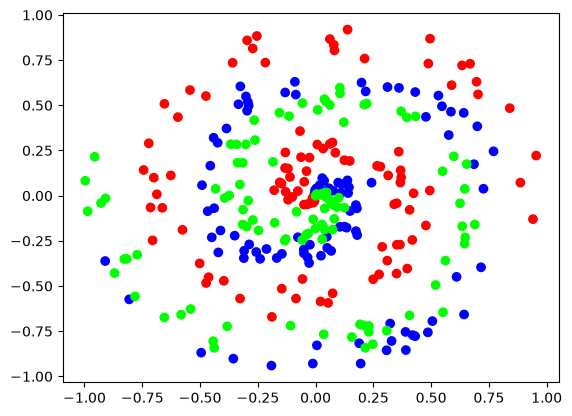

In [34]:
#Dataset
import matplotlib.pyplot as plt
X,y=spiral_data(samples=100,classes=3)
plt.scatter(X[:,0], X[:,1], c=y, cmap='brg')
plt.show()

In [24]:

#Dense layer

class Layer_dense:
    #Layer intialization
    def __init__(self, n_inputs, n_neurons):
        self.weights=0.01*np.random.randn(n_inputs, n_neurons)
        self.biases=np.zeros((1,n_neurons))

    #Forward pass
    def forward(self, inputs):
        #remember input values
        self.inputs=inputs
        #Calculate output values from inputs, weights, biases
        self.output=np.dot(inputs, self.weights)+self.biases

    def backward(self, dvalues):
        #gradients on parameters
        self.dweights=np.dot(self.inputs.T, dvalues)
        self.dbiases=np.sum(dvalues, axis=0,keepdims=True)

        #gradient on values
        self.dinputs=np.dot(dvalues, self.weights.T)

In [6]:
# Relu activation 
class Activation_Relu:
    #forward pass
    def forward(self,inputs):
        #Calculate output values from input
        self.inputs=inputs
        self.output=np.maximum(0,inputs)

        #Backward pass

    def backward(self, dvalues):
        #since we need to modify the original variable 
        #Make a copy of the values first

        self.dinputs=dvalues.copy()
        self.dinputs[self.inputs <= 0] =0


In [7]:
#Softmax activation

class Activation_Softmax:
    # Forward Pass
    def forward(self, inputs):
        #Get unnormalized probabilities
        exp_values=np.exp(inputs-np.max(inputs, axis=1, keepdims=True))
        #Normalize them for each sample
        probabilities=exp_values/np.sum(exp_values, axis=1, keepdims=True)
        self.output=probabilities

In [8]:
# Implementing the loss class

class Loss:
    # Calculates the data and regularization losses
    def calculate(self, output,y):
        #Calculate sample losses
        sample_losses=self.forward(output,y)
        #Calculate mean loss
        data_loss=np.mean(sample_losses)
        #return Loss
        return data_loss

#we implement the class loss just for the sake of simplicity
#So we can also see weight values

In [9]:
# Implemnting the categorical cross entropy class

class Loss_CategoricalCrossentropy(Loss):

    #Backward [ass
    def backward(self, dvalues, y_true):
        # Number of samples
        samples=len(dvalues)
        #number of labels in every sample
        labels=len(dvalues[0])
        # If labels are sparse, turn them into one-hot vector
        if len(y_true.shape)==1:
            y_true=np.eye(labels)[y_true]
        # calculate gradient
        self.dinputs=-y_true/dvalues
        #normalize gradient
        self.dinputs=self.dinputs/samples
    #forward pass 
    def forward(self,y_pred,y_true):
        samples=len(y_pred)
        #Clip data to prevent divisions by 0
        #Clip both sides to not drag mean towards any value
        y_pred_clipped=np.clip(y_pred, 1e-7,1-1e-7)
        if len(y_true.shape)==1:
            correct_confidences=y_pred_clipped[
                range(samples),
                y_true
            ]
            #Mask values -only for one-hot encoded labels
        elif len(y_true.shape)==2:
            correct_confidences = np.sum(
                y_pred_clipped*y_true,
                axis=1
            )
        #losses
        negative_log_likelihoods=-np.log(correct_confidences)
        return negative_log_likelihoods


In [10]:
class Activation_Softmax_Loss_categoricalCrossentropy:
    #creates activation and loss function objects
    def __init__(self):
        self.activation=Activation_Softmax()
        self.loss=Loss_CategoricalCrossentropy()

    #forward pass
    def forward(self, inputs, y_true):
        #Output layer's activation function
        self.activation.forward(inputs)
        # Set the output
        self.output=self.activation.output
        # Calculate and return loss values
        return self.loss.calculate(self.output, y_true)
    
        #Backward pass
    def backward(self, dvalues, y_true):
        samples=len(dvalues)
        if len(y_true.shape)==2:
            y_true=np.argmax(y_true, axis=1)
        self.dinputs=dvalues.copy()
        #calculate the gradient
        self.dinputs[range(samples), y_true]-=1
        #Normalize gradient
        self.dinputs=self.dinputs/samples



We will be performing 10000 iterations of Forward and backward pass and will update the parameters, as per update_param() rule i.e GD

In [33]:
X,y=spiral_data(samples=100, classes=3)

dense1=Layer_dense(2,64)
activation1=Activation_Relu()
dense2=Layer_dense(64,3)

loss_activation=Activation_Softmax_Loss_categoricalCrossentropy()
optimizer=GD_optimizer(learning_rate=1.1)

#Train in loop
for epoch in range(10001):
    #Perform a forward pass of our training data 
    dense1.forward(X)
    activation1.forward(dense1.output)

    #perform a forward pass through second dense layer
    dense2.forward(activation1.output)

    #taking the output of second dense layer and return loss
    loss=loss_activation.forward(dense2.output, y)

    #Calculate accuracy from output of activation2 and targets
    predictions=np.argmax(loss_activation.output, axis=1)
    if len(y.shape)==2:
        y=np.argmax(y, axis=1)
    accuracy=np.mean(predictions==y)

    if not epoch %100:
        print(f"epoch:{epoch},"+
              f'acc:{accuracy:.3f},'+
              f'loss:{loss:.3f}')
        
    #Backward pass
    loss_activation.backward(loss_activation.output, y)
    dense2.backward(loss_activation.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    #update weights and biases

    optimizer.update_param(dense1)
    optimizer.update_param(dense2)


epoch:0,acc:0.377,loss:1.099
epoch:100,acc:0.403,loss:1.078
epoch:200,acc:0.420,loss:1.069
epoch:300,acc:0.427,loss:1.068
epoch:400,acc:0.420,loss:1.067
epoch:500,acc:0.420,loss:1.066
epoch:600,acc:0.423,loss:1.062
epoch:700,acc:0.420,loss:1.057
epoch:800,acc:0.410,loss:1.056
epoch:900,acc:0.407,loss:1.050
epoch:1000,acc:0.410,loss:1.040
epoch:1100,acc:0.393,loss:1.028
epoch:1200,acc:0.470,loss:1.028
epoch:1300,acc:0.493,loss:1.010
epoch:1400,acc:0.470,loss:0.993
epoch:1500,acc:0.487,loss:1.028
epoch:1600,acc:0.487,loss:0.970
epoch:1700,acc:0.460,loss:0.959
epoch:1800,acc:0.513,loss:0.940
epoch:1900,acc:0.530,loss:0.935
epoch:2000,acc:0.543,loss:0.912
epoch:2100,acc:0.527,loss:0.878
epoch:2200,acc:0.510,loss:0.906
epoch:2300,acc:0.617,loss:0.828
epoch:2400,acc:0.557,loss:0.876
epoch:2500,acc:0.600,loss:0.819
epoch:2600,acc:0.613,loss:0.835
epoch:2700,acc:0.683,loss:0.717
epoch:2800,acc:0.627,loss:0.763
epoch:2900,acc:0.630,loss:0.755
epoch:3000,acc:0.620,loss:0.812
epoch:3100,acc:0.643